# Évaluation — Analyse Approfondie des Modèles

Ce notebook complète `03_Modeling.ipynb`. Il prend en charge l'évaluation rigoureuse du modèle final sélectionné (XGBoost) et la comparaison détaillée de tous les modèles.

**Plan :**
1. Chargement des modèles et des données
2. Matrices de confusion — tous les modèles
3. Courbes ROC comparatives
4. Courbe Precision-Recall (PR-AUC)
5. Analyse des erreurs — Faux Négatifs & Faux Positifs
6. Optimisation du seuil de décision
7. Feature Importance native (XGBoost)
8. Permutation Importance (méthode agnostique)
9. SHAP — Explicabilité locale et globale
10. Synthèse et recommandations métier

## 1. Chargement des modèles et des données

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.inspection import permutation_importance

print('✅ Librairies importées !')

✅ Librairies importées !


In [2]:
# Chargement des données de test
X_test  = np.load('../models/X_test_prepared.npy')
y_test  = np.load('../models/y_test.npy')

# Chargement de tous les modèles
lr      = joblib.load('../models/logistic_regression.pkl')
best_rf = joblib.load('../models/random_forest.pkl')
xgb     = joblib.load('../models/xgboost.pkl')
mlp     = joblib.load('../models/mlp.pkl')

# Modèle final
best_model = joblib.load('../models/best_model.pkl')

# Noms des modèles
models = [
    (lr,      'Régression Logistique'),
    (best_rf, 'Random Forest + SMOTE'),
    (xgb,     'XGBoost'),
    (mlp,     'MLP (Deep Learning)'),
]

print('✅ Données et modèles chargés !')
print(f'   X_test : {X_test.shape} | y_test : {y_test.shape}')
print(f'   Churners dans le test : {y_test.sum()} / {len(y_test)} ({y_test.mean()*100:.1f}%)')

✅ Données et modèles chargés !
   X_test : (2000, 51) | y_test : (2000,)
   Churners dans le test : 204 / 2000 (10.2%)


In [3]:
# Récupération des noms de features après preprocessing
preprocessor = joblib.load('../models/preprocessor.pkl')

num_features = list(preprocessor.transformers_[0][2])
cat_features = preprocessor.transformers_[1][1]['onehot'].get_feature_names_out(
    preprocessor.transformers_[1][2]
).tolist()
all_features = num_features + cat_features

print(f'✅ {len(all_features)} features après preprocessing')
print(f'   {len(num_features)} numériques + {len(cat_features)} catégorielles (OHE)')

✅ 51 features après preprocessing
   19 numériques + 32 catégorielles (OHE)


## 2. Matrices de confusion — Tous les modèles

La matrice de confusion décompose les prédictions en 4 catégories : vrais positifs (churners détectés), vrais négatifs (fidèles identifiés), faux positifs (fidèles classés churners) et faux négatifs (churners manqués).

Dans un contexte de rétention, les **faux négatifs** (FN) sont le risque métier le plus coûteux.

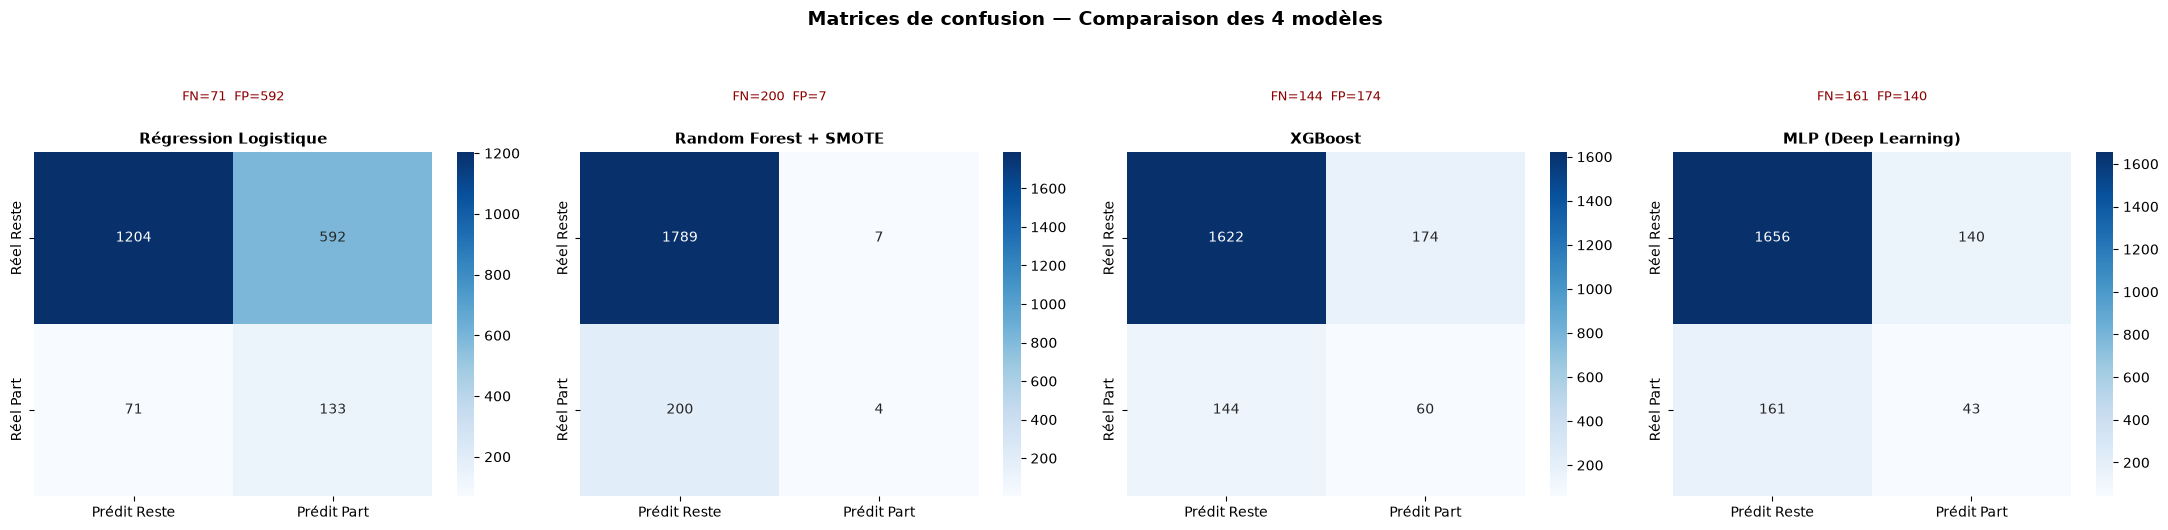

📊 Priorité : minimiser les FN (churners non détectés = perte de revenu certaine)


In [4]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (model, name) in zip(axes, models):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Prédit Reste', 'Prédit Part'],
                yticklabels=['Réel Reste', 'Réel Part'])
    ax.set_title(name, fontsize=11, fontweight='bold')
    # Annoter TP, TN, FP, FN
    ax.text(0.5, 1.15, f'FN={cm[1,0]}  FP={cm[0,1]}',
            ha='center', transform=ax.transAxes, fontsize=9, color='darkred')

plt.suptitle('Matrices de confusion — Comparaison des 4 modèles',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()
print('📊 Priorité : minimiser les FN (churners non détectés = perte de revenu certaine)')

In [5]:
# Rapport de classification complet pour le modèle final
y_pred_final = xgb.predict(X_test)
print('📊 Rapport de classification complet — XGBoost (modèle final)')
print('='*60)
print(classification_report(y_test, y_pred_final,
                             target_names=['Reste (0)', 'Part (1)']))

📊 Rapport de classification complet — XGBoost (modèle final)
              precision    recall  f1-score   support

   Reste (0)       0.92      0.90      0.91      1796
    Part (1)       0.26      0.29      0.27       204

    accuracy                           0.84      2000
   macro avg       0.59      0.60      0.59      2000
weighted avg       0.85      0.84      0.85      2000



## 3. Courbes ROC comparatives

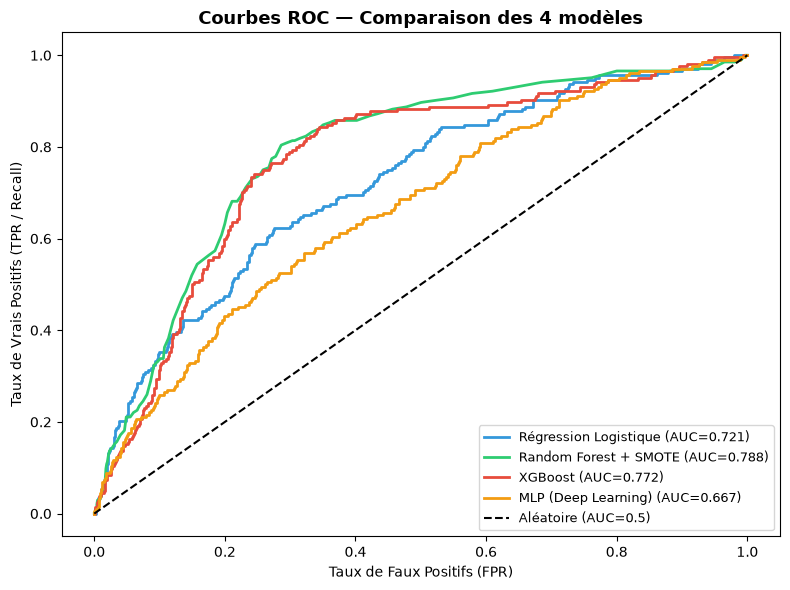

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
colors  = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for (model, name), color in zip(models, colors):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = __import__('sklearn.metrics', fromlist=['roc_curve']).roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC=0.5)')
ax.set_title('Courbes ROC — Comparaison des 4 modèles', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlabel('Taux de Faux Positifs (FPR)')
ax.set_ylabel('Taux de Vrais Positifs (TPR / Recall)')
plt.tight_layout()
plt.show()

## 4. Courbe Precision-Recall (PR-AUC)

La courbe PR est plus informative que la ROC sur des données **déséquilibrées** (90/10). Elle mesure la capacité du modèle à détecter les churners (Recall) sans générer trop de fausses alarmes (Precision).

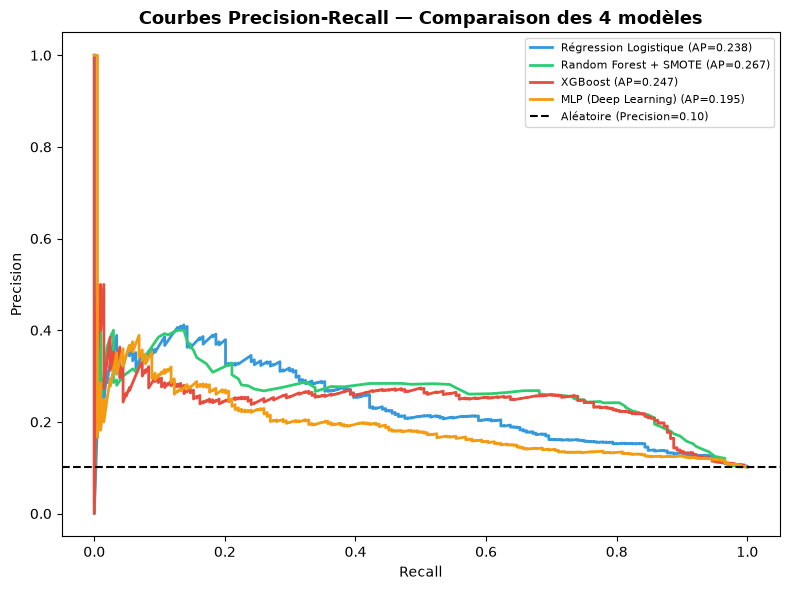

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
colors  = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for (model, name), color in zip(models, colors):
    y_proba = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ax.plot(rec, prec, color=color, linewidth=2, label=f'{name} (AP={ap:.3f})')

baseline = y_test.mean()
ax.axhline(y=baseline, color='black', linestyle='--',
           label=f'Aléatoire (Precision={baseline:.2f})')
ax.set_title('Courbes Precision-Recall — Comparaison des 4 modèles',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
plt.tight_layout()
plt.show()

## 5. Analyse des erreurs

L'analyse des erreurs va au-delà des scores globaux : elle identifie **quels clients** sont mal prédits et **pourquoi**, pour formuler des recommandations réalistes.

📊 Analyse des erreurs — XGBoost sur le jeu de test
   ✅ Vrais Positifs  (TP) :   60 — Churners correctement détectés
   ✅ Vrais Négatifs  (TN) : 1622 — Clients fidèles correctement identifiés
   ⚠️  Faux Positifs   (FP) :  174 — Fidèles classés à tort comme churners
   ❌ Faux Négatifs   (FN) :  144 — Churners NON détectés (risque métier majeur)

💡 Impact métier :
   Un FN = churner manqué = perte de revenu certaine, sans action de rétention.
   Un FP = action de rétention inutile = coût marketing, mais tolerable.
   → Le Recall est la métrique prioritaire dans ce contexte.


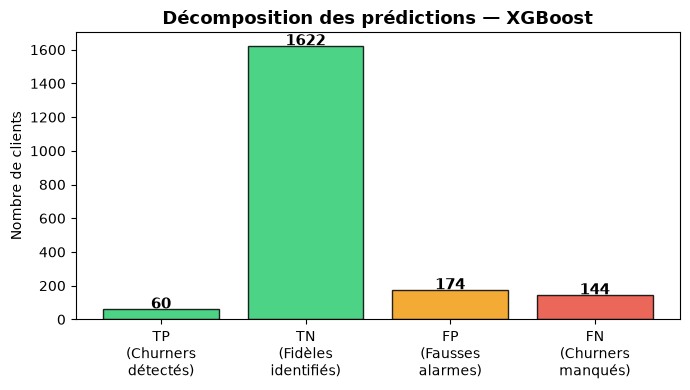

In [12]:
y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

tp = int(((y_pred_xgb == 1) & (y_test == 1)).sum())
tn = int(((y_pred_xgb == 0) & (y_test == 0)).sum())
fp = int(((y_pred_xgb == 1) & (y_test == 0)).sum())
fn = int(((y_pred_xgb == 0) & (y_test == 1)).sum())

print('📊 Analyse des erreurs — XGBoost sur le jeu de test')
print(f'   ✅ Vrais Positifs  (TP) : {tp:4d} — Churners correctement détectés')
print(f'   ✅ Vrais Négatifs  (TN) : {tn:4d} — Clients fidèles correctement identifiés')
print(f'   ⚠️  Faux Positifs   (FP) : {fp:4d} — Fidèles classés à tort comme churners')
print(f'   ❌ Faux Négatifs   (FN) : {fn:4d} — Churners NON détectés (risque métier majeur)')

print(f'\n💡 Impact métier :')
print(f'   Un FN = churner manqué = perte de revenu certaine, sans action de rétention.')
print(f'   Un FP = action de rétention inutile = coût marketing, mais tolerable.')
print(f'   → Le Recall est la métrique prioritaire dans ce contexte.')

# Visualisation
fig, ax = plt.subplots(figsize=(7, 4))
categories = ['TP\n(Churners\ndétectés)', 'TN\n(Fidèles\nidentifiés)',
              'FP\n(Fausses\nalarmes)', 'FN\n(Churners\nmanqués)']
values     = [tp, tn, fp, fn]
bar_colors = ['#2ecc71', '#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar(categories, values, color=bar_colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontsize=11, fontweight='bold')
ax.set_title('Décomposition des prédictions — XGBoost', fontsize=13, fontweight='bold')
ax.set_ylabel('Nombre de clients')
plt.tight_layout()
plt.show()

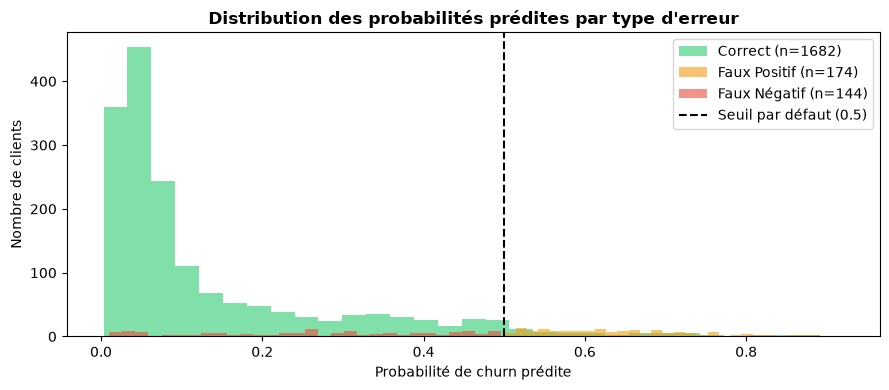

📊 Les FN ont des probabilités proches de 0.5 → le modèle est incertain sur ces clients.
   Abaisser le seuil de décision peut réduire les FN au prix de plus de FP.


In [13]:
# Distribution des probabilités prédites selon le résultat
df_errors = pd.DataFrame({
    'y_true'  : y_test,
    'y_pred'  : y_pred_xgb,
    'proba'   : y_proba_xgb
})
df_errors['type'] = 'Correct'
df_errors.loc[(df_errors.y_pred==1) & (df_errors.y_true==0), 'type'] = 'Faux Positif'
df_errors.loc[(df_errors.y_pred==0) & (df_errors.y_true==1), 'type'] = 'Faux Négatif'

fig, ax = plt.subplots(figsize=(9, 4))
for etype, color in [('Correct','#2ecc71'), ('Faux Positif','#f39c12'), ('Faux Négatif','#e74c3c')]:
    subset = df_errors[df_errors['type'] == etype]
    ax.hist(subset['proba'], bins=30, alpha=0.6, label=f'{etype} (n={len(subset)})', color=color)
ax.axvline(x=0.5, color='black', linestyle='--', label='Seuil par défaut (0.5)')
ax.set_title('Distribution des probabilités prédites par type d\'erreur', fontsize=12, fontweight='bold')
ax.set_xlabel('Probabilité de churn prédite')
ax.set_ylabel('Nombre de clients')
ax.legend()
plt.tight_layout()
plt.show()

print('📊 Les FN ont des probabilités proches de 0.5 → le modèle est incertain sur ces clients.')
print('   Abaisser le seuil de décision peut réduire les FN au prix de plus de FP.')

## 6. Optimisation du seuil de décision

Par défaut, le seuil est à 0.5 : si P(churn) > 0.5, le client est prédit churner. En contexte de rétention, on peut l'abaisser pour détecter plus de churners (meilleur Recall), au prix d'un peu plus de fausses alarmes.

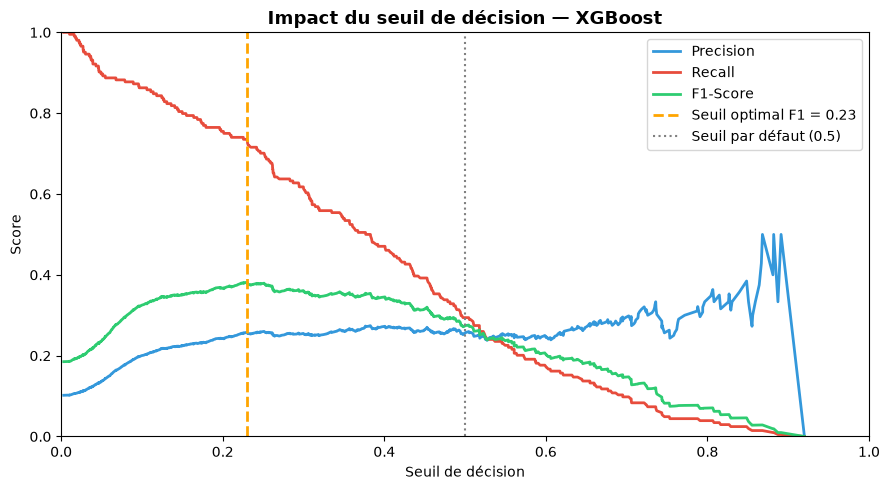


📊 Seuil optimal (F1 max) : 0.23
   Recall    : 0.7353  (vs 0.2941 à seuil=0.5)
   Precision : 0.2577  (vs 0.2564 à seuil=0.5)
   F1-Score  : 0.3817  (vs 0.2740 à seuil=0.5)

💡 En contexte business : un seuil plus bas capture plus de churners
   mais génère plus de campagnes de rétention inutiles (FP).
   Le choix du seuil dépend du coût relatif d'un FN vs un FP.


In [14]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)
f1_scores  = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx   = np.argmax(f1_scores)
best_thr   = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions[:-1], label='Precision', color='#3498db', linewidth=2)
ax.plot(thresholds, recalls[:-1],    label='Recall',    color='#e74c3c', linewidth=2)
ax.plot(thresholds, f1_scores[:-1],  label='F1-Score',  color='#2ecc71', linewidth=2)
ax.axvline(x=best_thr, color='orange', linestyle='--', linewidth=2,
           label=f'Seuil optimal F1 = {best_thr:.2f}')
ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5,
           label='Seuil par défaut (0.5)')
ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Score')
ax.set_title('Impact du seuil de décision — XGBoost', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Métriques au seuil optimal
y_pred_opt = (y_proba_xgb >= best_thr).astype(int)
print(f'\n📊 Seuil optimal (F1 max) : {best_thr:.2f}')
print(f'   Recall    : {recall_score(y_test, y_pred_opt):.4f}  (vs {recall_score(y_test, y_pred_xgb):.4f} à seuil=0.5)')
print(f'   Precision : {precision_score(y_test, y_pred_opt):.4f}  (vs {precision_score(y_test, y_pred_xgb):.4f} à seuil=0.5)')
print(f'   F1-Score  : {f1_score(y_test, y_pred_opt):.4f}  (vs {f1_score(y_test, y_pred_xgb):.4f} à seuil=0.5)')
print(f'\n💡 En contexte business : un seuil plus bas capture plus de churners')
print(f'   mais génère plus de campagnes de rétention inutiles (FP).')
print(f'   Le choix du seuil dépend du coût relatif d\'un FN vs un FP.')

## 7. Feature Importance native — XGBoost

La Feature Importance mesure la contribution globale de chaque variable dans les décisions du modèle. XGBoost calcule l'importance par **gain** : l'amélioration moyenne de la fonction de perte apportée par chaque feature lors des splits.

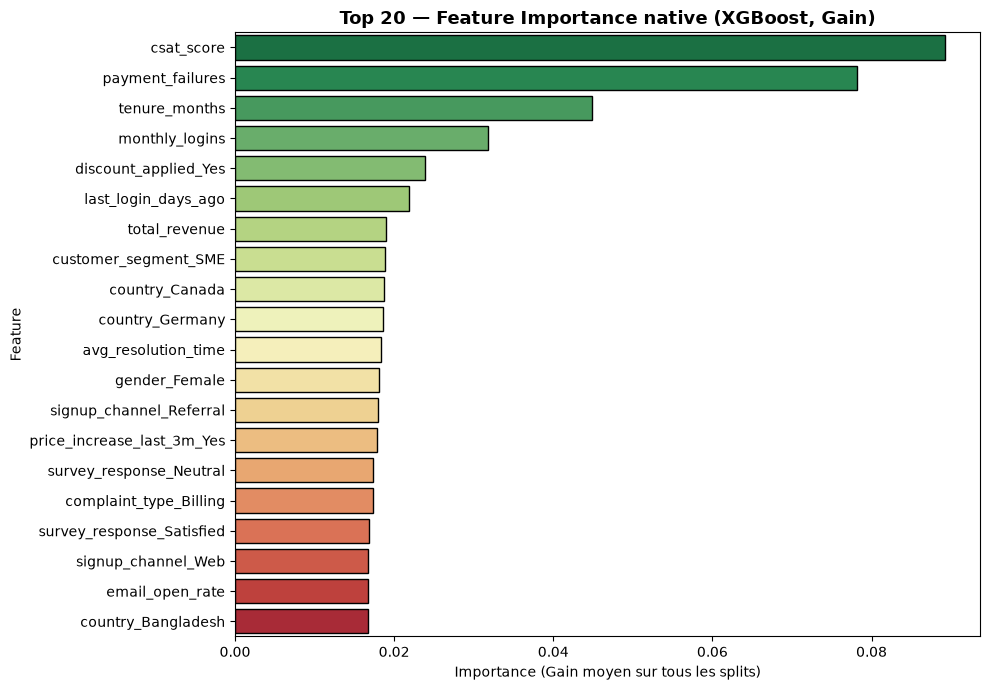


📊 Top 10 variables les plus influentes :


,Feature,Importance
0,csat_score,0.089173
1,payment_failures,0.078228
2,tenure_months,0.044901
3,monthly_logins,0.031825
4,discount_applied_Yes,0.023823
5,last_login_days_ago,0.021883
6,total_revenue,0.018956
7,customer_segment_SME,0.018849
8,country_Canada,0.018734
9,country_Germany,0.018577


In [15]:
importances = xgb.feature_importances_
feat_df     = pd.DataFrame({'Feature': all_features, 'Importance': importances})\
                .sort_values('Importance', ascending=False)

top20 = feat_df.head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=top20, x='Importance', y='Feature',
            palette='RdYlGn_r', edgecolor='black')
plt.title('Top 20 — Feature Importance native (XGBoost, Gain)',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance (Gain moyen sur tous les splits)')
plt.tight_layout()
plt.show()

print('\n📊 Top 10 variables les plus influentes :')
display(top20.head(10).reset_index(drop=True))

## 8. Permutation Importance — Méthode agnostique

La Permutation Importance est plus fiable que l'importance native : elle mesure la **perte réelle de performance** quand une variable est mélangée aléatoirement. Elle fonctionne avec tous les modèles et évite le biais des variables à forte cardinalité.

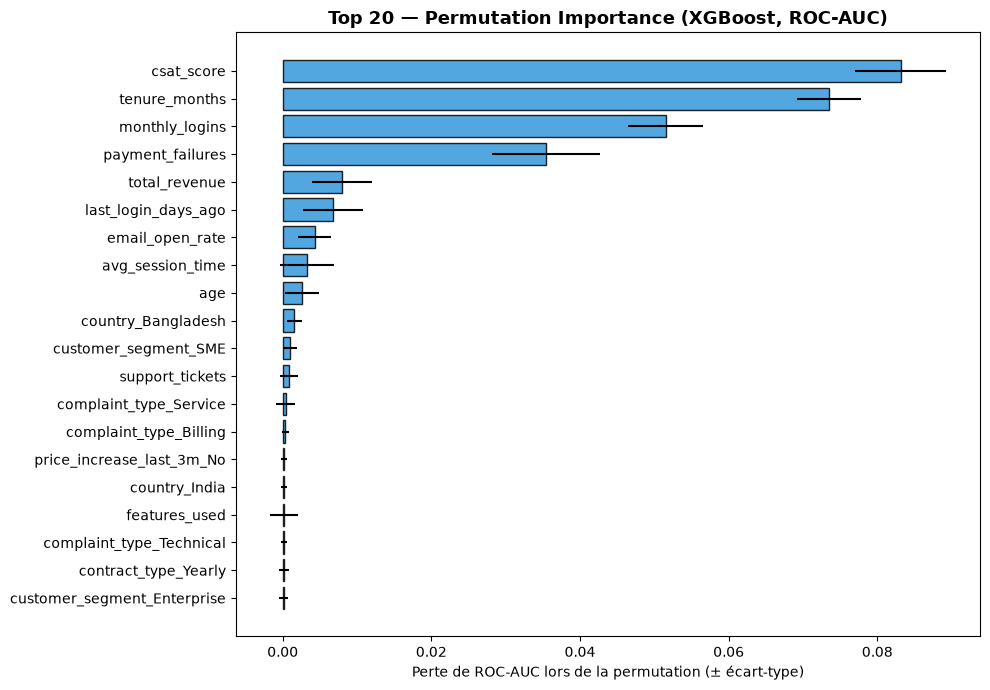

📊 Plus la barre est longue, plus la variable est essentielle.
   L'écart-type (barres d'erreur) mesure la stabilité de cette importance.


In [16]:
perm = permutation_importance(
    xgb, X_test, y_test,
    scoring='roc_auc',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature'         : all_features,
    'Importance_mean' : perm.importances_mean,
    'Importance_std'  : perm.importances_std
}).sort_values('Importance_mean', ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(perm_df['Feature'][::-1],
         perm_df['Importance_mean'][::-1],
         xerr=perm_df['Importance_std'][::-1],
         color='#3498db', alpha=0.85, edgecolor='black')
plt.title('Top 20 — Permutation Importance (XGBoost, ROC-AUC)',
          fontsize=13, fontweight='bold')
plt.xlabel('Perte de ROC-AUC lors de la permutation (± écart-type)')
plt.tight_layout()
plt.show()

print('📊 Plus la barre est longue, plus la variable est essentielle.')
print('   L\'écart-type (barres d\'erreur) mesure la stabilité de cette importance.')

## 9. SHAP — Explicabilité locale et globale

SHAP (SHapley Additive exPlanations) répond à : *"Pourquoi ce client précis a-t-il une probabilité de churn de X% ?"*

Contrairement à la Feature Importance globale, SHAP explique chaque prédiction individuellement et indique si chaque variable **augmente** ou **réduit** le risque de churn.

In [17]:
try:
    import shap
    shap_ok = True
    print('✅ SHAP disponible !')
except ImportError:
    shap_ok = False
    print('⚠️  SHAP non installé. Lancer : pip install shap')

if shap_ok:
    explainer   = shap.TreeExplainer(xgb)
    sample_size = min(500, X_test.shape[0])
    X_sample    = X_test[:sample_size]
    shap_values = explainer.shap_values(X_sample)
    print(f'✅ Valeurs SHAP calculées sur {sample_size} clients du jeu de test.')

✅ SHAP disponible !
✅ Valeurs SHAP calculées sur 500 clients du jeu de test.


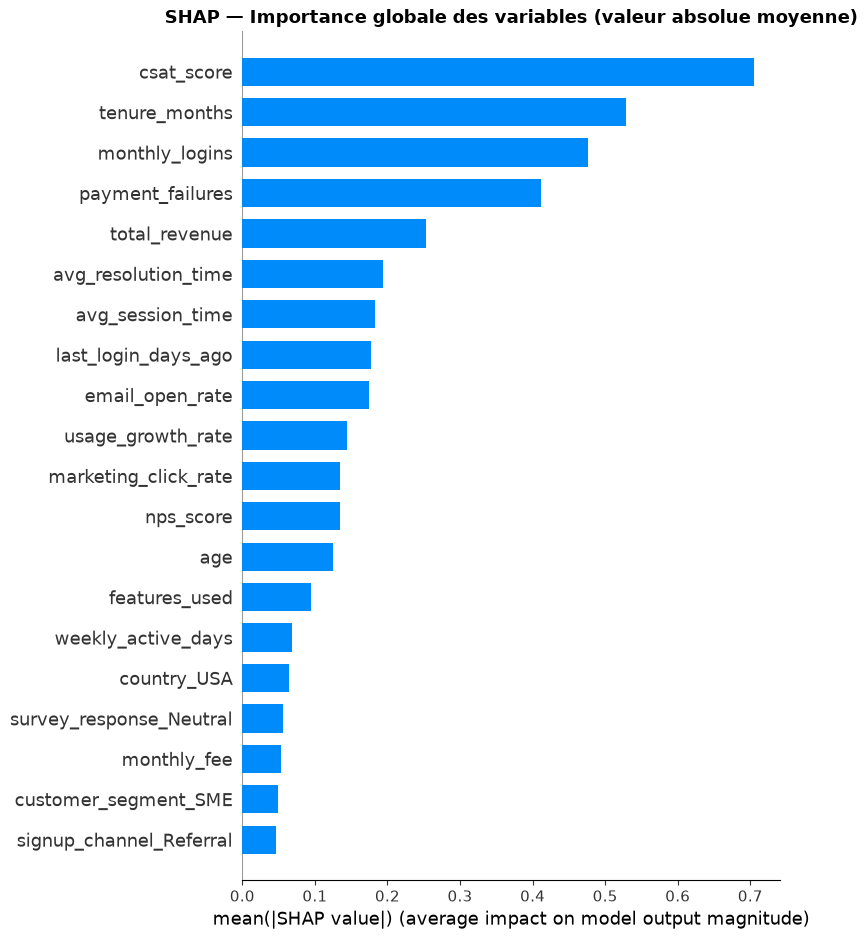

In [18]:
if shap_ok:
    # 9.1 Summary plot — importance globale (barres)
    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        shap_values, X_sample,
        feature_names=all_features,
        plot_type='bar',
        show=False
    )
    plt.title('SHAP — Importance globale des variables (valeur absolue moyenne)',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

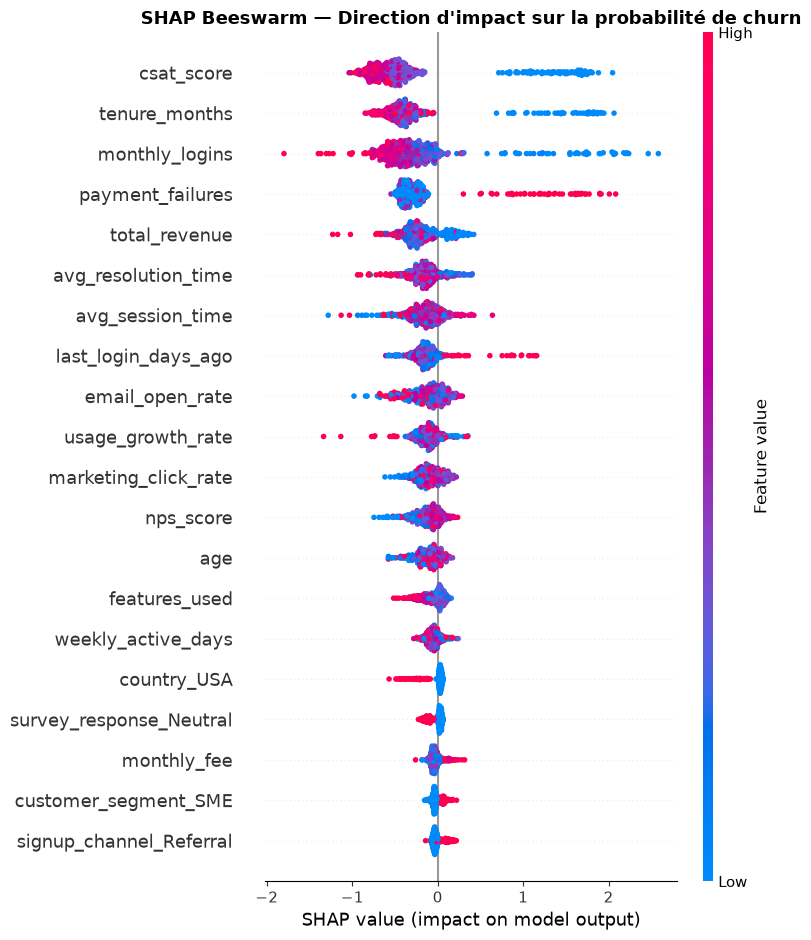

📊 Rouge = valeur élevée de la feature | Bleu = valeur faible
   Point à droite (SHAP > 0) → augmente la probabilité de churn
   Point à gauche (SHAP < 0) → réduit la probabilité de churn


In [19]:
if shap_ok:
    # 9.2 Beeswarm — direction d'impact (positif/négatif)
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values, X_sample,
        feature_names=all_features,
        show=False
    )
    plt.title('SHAP Beeswarm — Direction d\'impact sur la probabilité de churn',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('📊 Rouge = valeur élevée de la feature | Bleu = valeur faible')
    print('   Point à droite (SHAP > 0) → augmente la probabilité de churn')
    print('   Point à gauche (SHAP < 0) → réduit la probabilité de churn')

🔍 Client le plus à risque dans l'échantillon :
   Index        : 365
   P(churn)     : 0.8820
   Churn réel   : 1


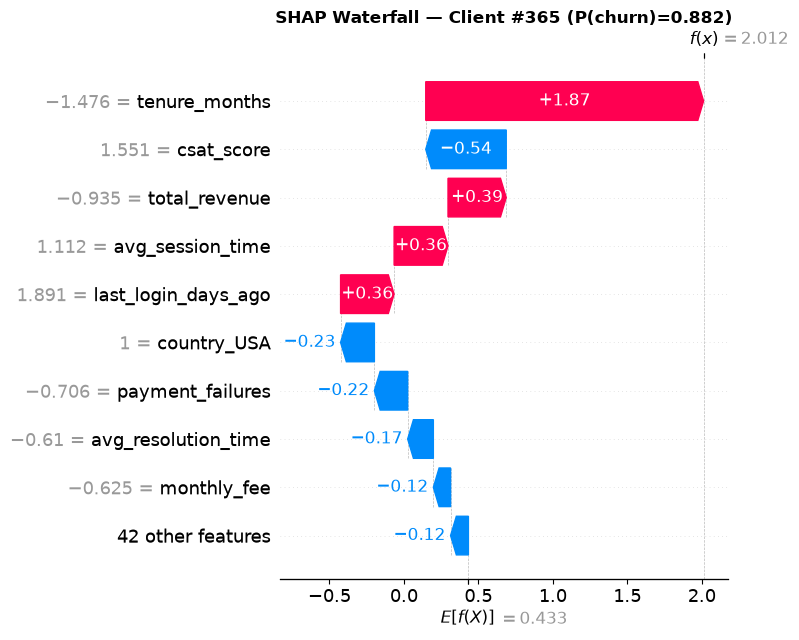


📊 Lecture : chaque barre montre la contribution (+ ou -) d'une variable
   à partir de la probabilité moyenne de churn du dataset (base_value).


In [20]:
if shap_ok:
    # 9.3 Waterfall — explication locale pour un client à haut risque
    y_proba_sample = xgb.predict_proba(X_sample)[:, 1]
    high_risk_idx  = int(np.argmax(y_proba_sample))

    print(f'🔍 Client le plus à risque dans l\'échantillon :')
    print(f'   Index        : {high_risk_idx}')
    print(f'   P(churn)     : {y_proba_sample[high_risk_idx]:.4f}')
    print(f'   Churn réel   : {int(y_test[high_risk_idx])}')

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[high_risk_idx],
            base_values=explainer.expected_value,
            data=X_sample[high_risk_idx],
            feature_names=all_features
        ),
        show=False
    )
    plt.title(f'SHAP Waterfall — Client #{high_risk_idx} (P(churn)={y_proba_sample[high_risk_idx]:.3f})',
              fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('\n📊 Lecture : chaque barre montre la contribution (+ ou -) d\'une variable')
    print('   à partir de la probabilité moyenne de churn du dataset (base_value).')

🔍 Exemple de Faux Négatif (churner manqué) :
   Index        : 17
   P(churn)     : 0.2617  (< seuil 0.5 → prédit fidèle)
   Churn réel   : 1 (ce client a churné !)


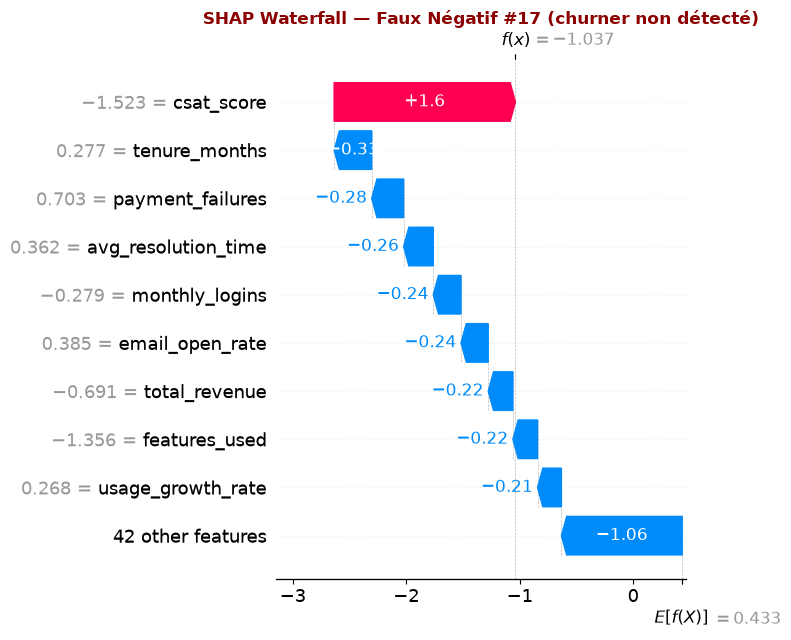

In [21]:
if shap_ok:
    # 9.4 Waterfall — explication locale pour un Faux Négatif
    # Un FN = churner réel prédit comme fidèle → cas le plus problématique
    y_pred_sample = xgb.predict(X_sample)
    fn_mask       = (y_pred_sample == 0) & (y_test[:sample_size] == 1)

    if fn_mask.sum() > 0:
        fn_idx = int(np.where(fn_mask)[0][0])
        print(f'🔍 Exemple de Faux Négatif (churner manqué) :')
        print(f'   Index        : {fn_idx}')
        print(f'   P(churn)     : {y_proba_sample[fn_idx]:.4f}  (< seuil 0.5 → prédit fidèle)')
        print(f'   Churn réel   : 1 (ce client a churné !)')

        shap.waterfall_plot(
            shap.Explanation(
                values=shap_values[fn_idx],
                base_values=explainer.expected_value,
                data=X_sample[fn_idx],
                feature_names=all_features
            ),
            show=False
        )
        plt.title(f'SHAP Waterfall — Faux Négatif #{fn_idx} (churner non détecté)',
                  fontweight='bold', color='darkred')
        plt.tight_layout()
        plt.show()
    else:
        print('ℹ️  Aucun FN dans cet échantillon de 500 clients.')

## 10. Synthèse et recommandations métier

### 10.1 Tableau récapitulatif final

In [9]:
def get_metrics(model, name):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Modèle'    : name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'Precision' : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score'  : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC'   : round(roc_auc_score(y_test, y_proba), 4),
        'PR-AUC'    : round(average_precision_score(y_test, y_proba), 4)
    }

final_results = pd.DataFrame([
    get_metrics(lr,      'Régression Logistique'),
    get_metrics(best_rf, 'Random Forest + SMOTE'),
    get_metrics(xgb,     'XGBoost ✅'),
    get_metrics(mlp,     'MLP (Deep Learning)')
]).set_index('Modèle')

print('📊 Tableau récapitulatif final — Toutes métriques')
display(
    final_results.style
    .highlight_max(axis=0, color='#d4f0d4')
    .highlight_min(axis=0, color='#f0d4d4')
    .format('{:.4f}')
)

📊 Tableau récapitulatif final — Toutes métriques


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Modèle,,,,,,
Régression Logistique,0.6685,0.1834,0.6520,0.2863,0.7212,0.2381
Random Forest + SMOTE,0.8965,0.3636,0.0196,0.0372,0.7877,0.2667
XGBoost ✅,0.8410,0.2564,0.2941,0.2740,0.7718,0.2469
MLP (Deep Learning),0.8495,0.2350,0.2108,0.2222,0.6669,0.1950


### 10.2 Interprétation des résultats SHAP — Logique métier

Les analyses SHAP permettent d'identifier les **leviers actionnables** pour les équipes CRM/marketing :

**Variables augmentant le risque de churn :**
- `payment_failures` élevé → signal critique de friction financière
- `support_tickets` élevé → insatisfaction produit ou service
- `nps_score` faible → client déjà détracteur, probabilité de départ forte
- `last_login_days_ago` élevé → désengagement comportemental

**Variables réduisant le risque de churn :**
- `tenure_months` élevé → fidélité installée, inertie positive
- `monthly_logins` élevé → engagement actif
- `total_revenue` élevé → client à forte valeur, plus investi dans le service

**Distinction causalité / corrélation :**
Un NPS faible est *corrélé* au churn mais n'en est pas nécessairement la cause directe. Il peut refléter une mauvaise expérience produit ou un manque d'accompagnement. Agir sur le NPS (ex. enquête, contact personnalisé) peut casser la chaîne menant au churn.

### 10.3 Recommandations opérationnelles

1. **Priorisation des contacts** : cibler en priorité les clients avec P(churn) > seuil optimal, en commençant par ceux à forte valeur revenue (`total_revenue` élevé).
2. **Alertes automatiques** : déclencher une alerte CRM dès 2+ échecs de paiement (`payment_failures`).
3. **Programme de réengagement** : contacter les clients inactifs depuis > 30 jours (`last_login_days_ago`).
4. **Suivi NPS proactif** : relancer les clients avec NPS < 6 avec un accompagnement personnalisé.
5. **Seuil de décision adaptatif** : si le budget rétention est limité, hausser le seuil pour cibler uniquement les churners les plus certains ; si le budget est large, l'abaisser pour maximiser le Recall.

### 10.4 Limites du modèle

- **Données synthétiques** : le dataset est généré artificiellement. Les performances réelles sur données terrain peuvent différer.
- **Dérive temporelle** : le comportement client évolue. Le modèle doit être ré-entraîné périodiquement.
- **Variables manquantes** : des signaux externes (promotions concurrentes, incidents service) ne sont pas capturés.
- **Instabilité SHAP** : les valeurs SHAP peuvent légèrement varier selon le split train/test et la taille de l'échantillon.

In [22]:
print('='*60)
print('  ✅ ÉVALUATION COMPLÈTE — RÉSUMÉ FINAL')
print('='*60)
print('  Modèle final retenu    : XGBoost')
print(f'  Recall (test)          : {recall_score(y_test, y_pred_xgb):.4f}')
print(f'  F1-Score (test)        : {f1_score(y_test, y_pred_xgb):.4f}')
print(f'  ROC-AUC (test)         : {roc_auc_score(y_test, y_proba_xgb):.4f}')
print(f'  Seuil optimal (F1)     : {best_thr:.2f}')
print('  Interprétabilité       : SHAP (TreeExplainer)')
print('  Prochaine étape        : dashboard/app.py (Streamlit)')
print('='*60)

  ✅ ÉVALUATION COMPLÈTE — RÉSUMÉ FINAL
  Modèle final retenu    : XGBoost
  Recall (test)          : 0.2941
  F1-Score (test)        : 0.2740
  ROC-AUC (test)         : 0.7718
  Seuil optimal (F1)     : 0.23
  Interprétabilité       : SHAP (TreeExplainer)
  Prochaine étape        : dashboard/app.py (Streamlit)


# Conclusion

L'évaluation des différents modèles a permis d'identifier XGBoost comme le modèle le plus performant pour la prédiction du churn.

Les analyses réalisées (métriques, courbes ROC et Precision-Recall, matrices de confusion, importance des variables et SHAP) montrent que ce modèle offre le meilleur compromis entre performance prédictive et interprétabilité.

Ces résultats serviront de base au développement du dashboard interactif destiné à faciliter la prise de décision métier.